# UC4 â€” Brute Force Detection: CICIDS2017 Data Preparation

**Goal:** Prepare training and test sets for a supervised XGBoost classifier
that distinguishes benign network flows from brute-force attacks
(FTP-Patator, SSH-Patator).

### Relationship to UC2

UC2 and UC4 both operate on CICIDS2017 network flow data but target
fundamentally different attack families:

| | UC2 (DDoS) | UC4 (Brute Force) |
|---|---|---|
| **Attack type** | Volumetric flooding | Credential-based repeated auth |
| **Source data** | Friday afternoon DDoS | Tuesday Brute Force |
| **Mechanism** | High packet/byte rates, sustained | Short connections, RST flags, specific ports |

Both use the **same reduced feature set** (`flow_feature_cols.json`) to
guarantee feature parity in the Detection microservice â€” one flow in,
two independent model predictions out.

### Inputs

| File | Source | Role |
|------|--------|------|
| Monday CSV | CICIDS2017 raw | Benign baseline (training only) |
| Tuesday CSV | CICIDS2017 raw | Benign + FTP-Patator + SSH-Patator |
| `flow_feature_cols.json` | UC2 data prep output | Shared feature set |

### Outputs

| File | Description |
|------|-------------|
| `train.csv` | Monday benign + first 70% of Tuesday |
| `test.csv` | Last 30% of Tuesday |

### Design Constraints

- **Feature parity with UC2** â€” both models consume identical feature columns.
- **No circular labeling** â€” labels from CIC ground truth annotations.
- **Temporal split** â€” 70/30 within Tuesday, snapped to second boundary.
- **Cleaning mirrors UC2** â€” same CICFlowMeter quirk handling.

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded.')

Libraries loaded.


## 1. Configuration

In [2]:
# â”€â”€ Paths â”€â”€
RAW_DATA_DIR = './data/CIC-IDS-2017/'
FEAT_DIR = './data/'
OUTPUT_DIR   = './data/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Raw CICIDS2017 CSV files
RAW_FILES = {
    'monday':  'Monday-WorkingHours.pcap_ISCX.csv',
    'tuesday': 'Tuesday-WorkingHours.pcap_ISCX.csv',
}

# UC2 feature list (shared for feature parity)
FEAT_JSON = os.path.join(FEAT_DIR, 'flow_feature_cols.json')

# Attack labels in Tuesday (CIC ground truth)
ATTACK_LABELS = ['FTP-Patator', 'SSH-Patator']

# â”€â”€ Split parameters â”€â”€
TUESDAY_TRAIN_RATIO = 0.70
SEED = 42

print('Configuration:')
for k, v in [('RAW_DATA_DIR', RAW_DATA_DIR), ('DATA_DIR', FEAT_DIR),
             ('OUTPUT_DIR', OUTPUT_DIR), ('TUESDAY_TRAIN_RATIO', TUESDAY_TRAIN_RATIO)]:
    print(f'  {k:25s}  {v}')

Configuration:
  RAW_DATA_DIR               ./data/CIC-IDS-2017/
  DATA_DIR                   ./data/
  OUTPUT_DIR                 ./data/
  TUESDAY_TRAIN_RATIO        0.7


## 2. Load UC2 Feature Columns

Feature parity between UC2 and UC4 is enforced by sharing the same
reduced feature set. UC2's data prep performed correlation-based
feature reduction (threshold 0.95) and exported the surviving columns.
UC4 consumes this list as-is â€” no independent feature selection.

In [3]:
with open(FEAT_JSON) as f:
    feature_cols = json.load(f)

print(f'Loaded {len(feature_cols)} feature columns from UC2:')
for i, c in enumerate(feature_cols, 1):
    print(f'  {i:3d}. {c}')

Loaded 43 feature columns from UC2:
    1. Protocol
    2. Total Backward Packets
    3. Total Length of Fwd Packets
    4. Fwd Packet Length Max
    5. Fwd Packet Length Min
    6. Fwd Packet Length Mean
    7. Bwd Packet Length Min
    8. Bwd Packet Length Std
    9. Flow Bytes/s
   10. Flow Packets/s
   11. Flow IAT Mean
   12. Flow IAT Std
   13. Flow IAT Min
   14. Fwd IAT Total
   15. Fwd IAT Mean
   16. Fwd IAT Std
   17. Fwd IAT Min
   18. Bwd IAT Total
   19. Bwd IAT Mean
   20. Bwd IAT Std
   21. Bwd IAT Max
   22. Fwd PSH Flags
   23. Fwd Header Length
   24. Bwd Header Length
   25. Bwd Packets/s
   26. Min Packet Length
   27. Packet Length Std
   28. Packet Length Variance
   29. FIN Flag Count
   30. PSH Flag Count
   31. ACK Flag Count
   32. URG Flag Count
   33. Down/Up Ratio
   34. Init_Win_bytes_forward
   35. Init_Win_bytes_backward
   36. min_seg_size_forward
   37. Active Mean
   38. Active Std
   39. Active Max
   40. Active Min
   41. Idle Std
   42. Idle Max
 

## 3. Load Raw CICIDS2017 Data

Load from raw CSVs (same files as UC2 data prep). Cleaning mirrors
`uc2_cicids2017_data_prep.ipynb`: strip CICFlowMeter's leading-space
column names, replace infinity with NaN, fill NaN with 0.

In [4]:
def load_and_clean(filepath, source_label):
    """Load a raw CICIDS2017 CSV with standard CICFlowMeter cleaning."""
    df = pd.read_csv(filepath, low_memory=False, encoding='utf-8')

    # CICFlowMeter quirk: leading whitespace in column names
    df.columns = df.columns.str.strip()

    # Parse timestamps
    if 'Timestamp' in df.columns:
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], dayfirst=True)
    else:
        print(f'  WARNING: No Timestamp column in {source_label} â€” '
              f'will use row order for temporal split.')

    # Replace inf with NaN, then fill NaN with 0
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
    df[numeric_cols] = df[numeric_cols].fillna(0)

    # Track source
    df['_source'] = source_label

    return df


dfs = {}
for key, fname in RAW_FILES.items():
    path = os.path.join(RAW_DATA_DIR, fname)
    if not os.path.exists(path):
        raise FileNotFoundError(f'Required file not found: {path}')
    df = load_and_clean(path, key)
    dfs[key] = df
    print(f'{key:12s}  {len(df):>10,} flows  '
          f'[{df["Label"].value_counts().to_dict()}]')

print(f'\nLoaded {len(dfs)} file(s).')

monday           529,918 flows  [{'BENIGN': 529918}]


tuesday          445,909 flows  [{'BENIGN': 432074, 'FTP-Patator': 7938, 'SSH-Patator': 5897}]

Loaded 2 file(s).


## 4. Verify UC2 Feature Columns Exist in Raw Data

In [5]:
for key, df in dfs.items():
    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        print(f'ERROR: {key} missing {len(missing)} feature columns: {missing[:5]}...')
    else:
        print(f'  {key:12s}  all {len(feature_cols)} UC2 feature columns present')

  monday        all 43 UC2 feature columns present
  tuesday       all 43 UC2 feature columns present


## 5. Tuesday Attack Distribution

Verify attack labels and their temporal distribution within Tuesday.
This informs whether the 70/30 temporal split captures both attack
types in both partitions.

In [6]:
df_tue = dfs['tuesday']

print('â”€â”€ Label distribution â”€â”€')
label_counts = df_tue['Label'].value_counts()
for label, count in label_counts.items():
    pct = 100 * count / len(df_tue)
    print(f'  {label:20s}  {count:>10,}  ({pct:5.2f}%)')

print(f'\nTotal:  {len(df_tue):>10,}')
print(f'Attack: {df_tue["Label"].isin(ATTACK_LABELS).sum():>10,}  '
      f'({100 * df_tue["Label"].isin(ATTACK_LABELS).mean():.2f}%)')

â”€â”€ Label distribution â”€â”€
  BENIGN                   432,074  (96.90%)
  FTP-Patator                7,938  ( 1.78%)
  SSH-Patator                5,897  ( 1.32%)

Total:     445,909
Attack:     13,835  (3.10%)


In [7]:
# Temporal distribution of attacks within Tuesday
if 'Timestamp' in df_tue.columns:
    df_tue_sorted = df_tue.sort_values('Timestamp')

    for label in ATTACK_LABELS:
        mask = df_tue_sorted['Label'] == label
        if mask.sum() > 0:
            ts_min = df_tue_sorted.loc[mask, 'Timestamp'].min()
            ts_max = df_tue_sorted.loc[mask, 'Timestamp'].max()
            print(f'{label:20s}  {mask.sum():>8,} flows  [{ts_min} â€” {ts_max}]')

    # Hourly breakdown
    print('\nâ”€â”€ Hourly attack distribution â”€â”€')
    df_tue_attacks = df_tue_sorted[df_tue_sorted['Label'].isin(ATTACK_LABELS)].copy()
    if len(df_tue_attacks) > 0:
        df_tue_attacks['hour'] = df_tue_attacks['Timestamp'].dt.hour
        hourly = df_tue_attacks.groupby(['hour', 'Label']).size().unstack(fill_value=0)
        print(hourly.to_string())
else:
    print('No Timestamp column â€” cannot show temporal distribution.')

for label in ATTACK_LABELS:
    mask = df_tue['Label'] == label
    if mask.sum() > 0:
        ts = df_tue.loc[mask, 'Timestamp']
        print(f'{label:20s}  {mask.sum():>8,} flows  '
              f'[{ts.min()} â€” {ts.max()}]')

# Also show what % of rows each minute-boundary would give
print(f'\nTotal Tuesday rows: {len(df_tue):,}')
for pct in [0.30, 0.40, 0.50, 0.60]:
    idx = int(len(df_tue) * pct)
    ts = df_tue.iloc[idx]['Timestamp']
    print(f'  {pct:.0%} boundary â†’ {ts}')

FTP-Patator              7,938 flows  [2017-07-04 09:17:00 â€” 2017-07-04 10:30:00]
SSH-Patator              5,897 flows  [2017-07-04 02:09:00 â€” 2017-07-04 03:11:00]

â”€â”€ Hourly attack distribution â”€â”€
Label  FTP-Patator  SSH-Patator
hour                           
2                0         4899
3                0          998
9             5266            0
10            2672            0


FTP-Patator              7,938 flows  [2017-07-04 09:17:00 â€” 2017-07-04 10:30:00]
SSH-Patator              5,897 flows  [2017-07-04 02:09:00 â€” 2017-07-04 03:11:00]

Total Tuesday rows: 445,909
  30% boundary â†’ 2017-07-04 01:07:00
  40% boundary â†’ 2017-07-04 02:06:00
  50% boundary â†’ 2017-07-04 03:28:00
  60% boundary â†’ 2017-07-04 03:45:00


## 6. Binary Labeling

Convert CIC's multi-class labels to binary: BENIGN (0) vs Brute Force (1).
Only FTP-Patator and SSH-Patator are marked as attack. Any other labels
in Tuesday (should be only BENIGN) remain as class 0.

In [8]:
# Combine into single DataFrame
df_all = pd.concat([dfs['monday'], dfs['tuesday']], ignore_index=True)

# Binary label: 1 = attack (FTP-Patator or SSH-Patator), 0 = benign
df_all['label'] = df_all['Label'].isin(ATTACK_LABELS).astype(int)
df_all['attack_type'] = df_all['Label'] 

print(f'Combined dataset: {len(df_all):>10,} flows')
print(f'  Monday:   {(df_all["_source"] == "monday").sum():>10,}  (all benign)')
print(f'  Tuesday:  {(df_all["_source"] == "tuesday").sum():>10,}')
print()
print(f'Label distribution:')
print(f'  Benign (0): {(df_all["label"] == 0).sum():>10,}  '
      f'({100 * (df_all["label"] == 0).mean():.2f}%)')
print(f'  Attack (1): {(df_all["label"] == 1).sum():>10,}  '
      f'({100 * (df_all["label"] == 1).mean():.2f}%)')

# Verify Monday is all benign
assert (df_all.loc[df_all['_source'] == 'monday', 'label'] == 0).all(), \
    'Monday contains non-benign labels!'
print('\n Monday is 100% benign.')

Combined dataset:    975,827 flows
  Monday:      529,918  (all benign)


  Tuesday:     445,909

Label distribution:
  Benign (0):    961,992  (98.58%)
  Attack (1):     13,835  (1.42%)

 Monday is 100% benign.


## 7. Temporal Train/Test Split

**Strategy** (mirrors UC2 data prep):

| Partition | Source |
|-----------|--------|
| **Train** | All Monday (benign) + first 70% of Tuesday |
| **Test**  | Last 30% of Tuesday |

The split boundary is placed at the nearest timestamp that doesn't
split flows within the same second.

In [9]:
monday_mask  = df_all['_source'] == 'monday'
tuesday_mask = df_all['_source'] == 'tuesday'

df_monday  = df_all[monday_mask].copy()
df_tue = df_all[tuesday_mask].copy()

print(f'Monday rows:   {len(df_monday):>10,}  (all train)')
print(f'Tuesday rows:  {len(df_tue):>10,}  (to be split)')

if 'Timestamp' in df_tue.columns and df_tue['Timestamp'].notna().all():
    # Sort by timestamp for temporal ordering
    df_tue = df_tue.sort_values('Timestamp').reset_index(drop=True)

    # Find split boundary
    split_idx = int(len(df_tue) * TUESDAY_TRAIN_RATIO)
    split_ts  = df_tue.iloc[split_idx]['Timestamp']

    # Snap to second boundary
    split_ts_floor = split_ts.floor('s')
    tue_train_mask = df_tue['Timestamp'] < split_ts_floor
    tue_test_mask  = df_tue['Timestamp'] >= split_ts_floor

    df_tue_train = df_tue[tue_train_mask].copy()
    df_tue_test  = df_tue[tue_test_mask].copy()

    print(f'\nTuesday split boundary: {split_ts_floor}')
else:
    # Fallback: row order (CICFlowMeter output is in capture order)
    split_idx = int(len(df_tue) * TUESDAY_TRAIN_RATIO)
    df_tue_train = df_tue.iloc[:split_idx].copy()
    df_tue_test  = df_tue.iloc[split_idx:].copy()
    print(f'\nTuesday split boundary: row index {split_idx}  (no Timestamp)')

# Combine Monday + Tuesday-train
df_train = pd.concat([df_monday, df_tue_train], ignore_index=True)
df_test  = df_tue_test.reset_index(drop=True)

print(f'\nTrain: {len(df_train):>10,} rows')
print(f'Test:  {len(df_test):>10,} rows')

Monday rows:      529,918  (all train)
Tuesday rows:     445,909  (to be split)



Tuesday split boundary: 2017-07-04 09:59:00



Train:    841,133 rows
Test:     134,694 rows


## 8. Split Label Distributions

In [10]:
for name, df in [('Train', df_train), ('Test', df_test)]:
    n_total  = len(df)
    n_attack = (df['label'] == 1).sum()
    n_benign = (df['label'] == 0).sum()
    print(f'â”€â”€ {name} â”€â”€')
    print(f'  Total:     {n_total:>10,}')
    print(f'  Benign:    {n_benign:>10,}  ({100 * n_benign / n_total:.2f}%)')
    print(f'  Attack:    {n_attack:>10,}  ({100 * n_attack / n_total:.2f}%)')
    if n_attack > 0:
        print(f'  Imbalance: 1:{n_benign // max(n_attack, 1)}')
        # Per-attack-type breakdown
        for label in ATTACK_LABELS:
            count = (df['Label'] == label).sum()
            if count > 0:
                print(f'    {label:20s}  {count:>8,}')
    print()

# Verify no temporal leakage
if 'Timestamp' in df_train.columns and 'Timestamp' in df_test.columns:
    train_max = df_train['Timestamp'].max()
    test_min  = df_test['Timestamp'].min()
    print(f'Train max timestamp: {train_max}')
    print(f'Test min timestamp:  {test_min}')
    assert train_max <= test_min, 'TEMPORAL LEAKAGE DETECTED!'
    print('No temporal leakage â€” train ends before test begins.')

â”€â”€ Train â”€â”€
  Total:        841,133
  Benign:       830,102  (98.69%)
  Attack:        11,031  (1.31%)
  Imbalance: 1:75
    FTP-Patator              5,134
    SSH-Patator              5,897

â”€â”€ Test â”€â”€
  Total:        134,694
  Benign:       131,890  (97.92%)
  Attack:         2,804  (2.08%)
  Imbalance: 1:47


    FTP-Patator              2,804

Train max timestamp: 2017-07-04 09:58:00
Test min timestamp:  2017-07-04 09:59:00
No temporal leakage â€” train ends before test begins.


## 9. Verify Attack Presence in Both Splits

The temporal split must not accidentally place all attacks in one
partition. Both FTP-Patator and SSH-Patator should appear in both
train and test if they span a sufficient time range.

In [11]:
print(f'{"Attack Type":20s}  {"Train":>10s}  {"Test":>10s}')
print('-' * 45)
for label in ATTACK_LABELS:
    n_train = (df_train['Label'] == label).sum()
    n_test  = (df_test['Label'] == label).sum()
    status = 'OK' if n_train > 0 and n_test > 0 else 'MISSING'
    print(f'{label:20s}  {n_train:>10,}  {n_test:>10,}  {status}')

# If any attack type is missing from test, warn but don't fail â€”
# some attacks may be time-concentrated in the first 70%
train_attacks = (df_train['label'] == 1).sum()
test_attacks  = (df_test['label'] == 1).sum()
print(f'\nTotal attacks â€” Train: {train_attacks:,}, Test: {test_attacks:,}')

if test_attacks == 0:
    print('\nWARNING: No attacks in test set! The temporal split may need adjustment.')
elif any((df_test['Label'] == label).sum() == 0 for label in ATTACK_LABELS):
    print('\nWARNING: Some attack types missing from test. '
          'Consider this in evaluation â€” per-type metrics may be incomplete.')
else:
    print('Both attack types present in both partitions.')

Attack Type                Train        Test
---------------------------------------------
FTP-Patator                5,134       2,804  OK


SSH-Patator                5,897           0  MISSING

Total attacks â€” Train: 11,031, Test: 2,804



## 10. Sanity Checks

In [12]:
for name, df in [('Train', df_train), ('Test', df_test)]:
    feat_data = df[feature_cols]
    n_nan = feat_data.isna().sum().sum()
    n_inf = np.isinf(feat_data.select_dtypes(include=np.number)).sum().sum()
    n_dup = df.duplicated(subset=feature_cols + ['label']).sum()

    status = 'OK' if n_nan == 0 and n_inf == 0 else 'Not OK'
    print(f'{status}  {name:6s}  NaN: {n_nan:,}  Inf: {n_inf:,}  '
          f'Duplicates: {n_dup:,}  Shape: {feat_data.shape}')

print()
print(f'Feature columns: {len(feature_cols)}')
print(f'Train rows:      {len(df_train):,}')
print(f'Test rows:       {len(df_test):,}')

OK  Train   NaN: 0  Inf: 0  Duplicates: 106,160  Shape: (841133, 43)


OK  Test    NaN: 0  Inf: 0  Duplicates: 13,080  Shape: (134694, 43)

Feature columns: 43
Train rows:      841,133
Test rows:       134,694


## 11. Feature Distribution: Benign vs Brute Force

Quick visual check that brute-force flows have distinguishable feature
distributions. This informs whether supervised classification is viable.

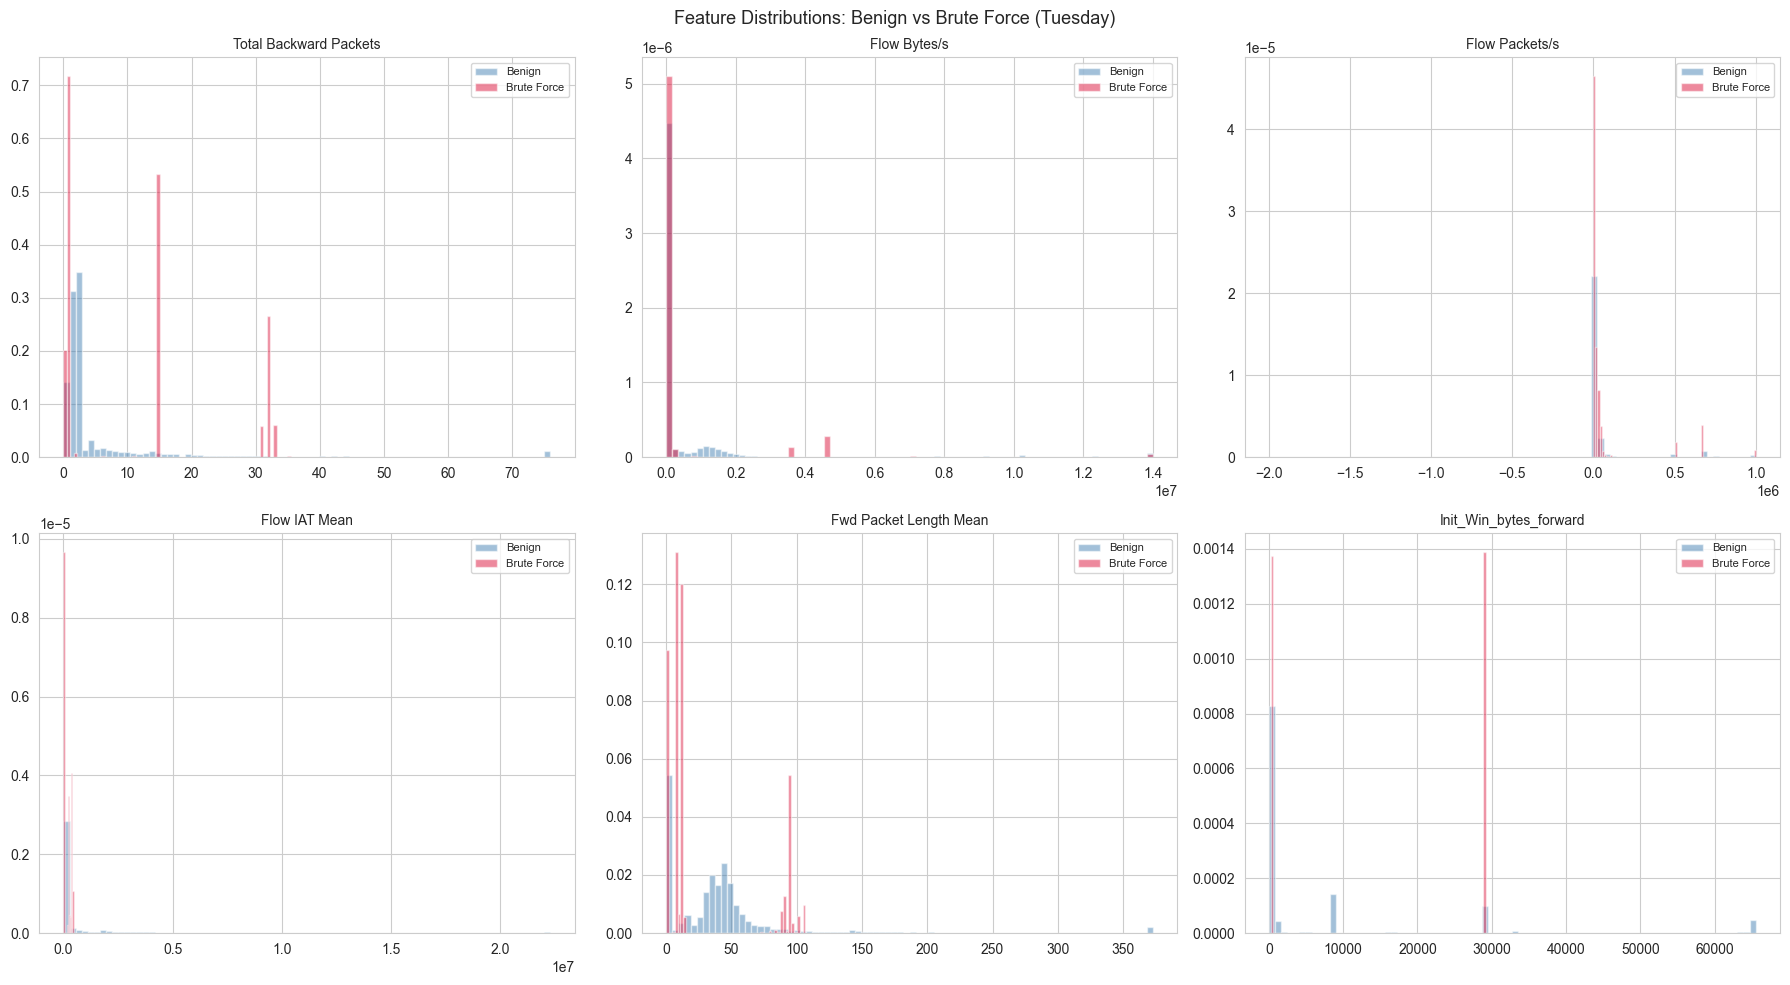

In [13]:
# Pick features likely discriminative for brute force
DIAGNOSTIC_FEATURES = [c for c in [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean',
    'Fwd Packet Length Mean', 'SYN Flag Count', 'RST Flag Count',
    'Init_Win_bytes_forward',
] if c in feature_cols]

# If the above are not in the reduced set, fall back to first 6
if len(DIAGNOSTIC_FEATURES) < 4:
    DIAGNOSTIC_FEATURES = feature_cols[:6]

n_diag = min(len(DIAGNOSTIC_FEATURES), 6)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Use Tuesday data only (Monday has no attacks)
df_tue_all = df_all[df_all['_source'] == 'tuesday']

for ax, feat in zip(axes[:n_diag], DIAGNOSTIC_FEATURES[:n_diag]):
    benign_vals = df_tue_all.loc[df_tue_all['label'] == 0, feat]
    attack_vals = df_tue_all.loc[df_tue_all['label'] == 1, feat]

    # Clip extreme outliers for visualization
    p99 = np.percentile(pd.concat([benign_vals, attack_vals]).dropna(), 99)
    ax.hist(benign_vals.clip(upper=p99), bins=80, alpha=0.5,
            density=True, label='Benign', color='steelblue')
    ax.hist(attack_vals.clip(upper=p99), bins=80, alpha=0.5,
            density=True, label='Brute Force', color='crimson')
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)

for ax in axes[n_diag:]:
    ax.set_visible(False)

plt.suptitle('Feature Distributions: Benign vs Brute Force (Tuesday)', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Class Imbalance Analysis

In [14]:
train_benign = (df_train['label'] == 0).sum()
train_attack = (df_train['label'] == 1).sum()
imbalance_ratio = train_benign / max(train_attack, 1)

print(f'Training set class balance:')
print(f'  Benign: {train_benign:>10,}')
print(f'  Attack: {train_attack:>10,}')
print(f'  Ratio:  1:{imbalance_ratio:.0f}')
print(f'  scale_pos_weight for XGBoost: {imbalance_ratio:.2f}')
print()
print('Note: XGBoost training notebook should use')
print(f'  scale_pos_weight = {imbalance_ratio:.2f}')
print('to compensate for class imbalance (same approach as UC2).')

Training set class balance:
  Benign:    830,102
  Attack:     11,031
  Ratio:  1:75
  scale_pos_weight for XGBoost: 75.25

Note: XGBoost training notebook should use
  scale_pos_weight = 75.25
to compensate for class imbalance (same approach as UC2).


## 13. Export Prepared Data

Export train and test CSVs with UC2 feature columns + label.
Metadata columns (Timestamp, Source IP, Label, _source) are excluded
from the exported CSVs â€” only numeric features and the binary label.

In [15]:
export_cols = feature_cols + ['label', 'attack_type']

# Verify all export columns exist
for c in export_cols:
    assert c in df_train.columns, f'Missing in train: {c}'
    assert c in df_test.columns,  f'Missing in test: {c}'

train_path = os.path.join(OUTPUT_DIR, 'train.csv')
test_path  = os.path.join(OUTPUT_DIR, 'test.csv')

df_train[export_cols].to_csv(train_path, index=False)
df_test[export_cols].to_csv(test_path, index=False)

print(f'Exported:')
print(f'  {train_path}  ({len(df_train):>10,} rows, {len(export_cols)} cols)')
print(f'  {test_path}   ({len(df_test):>10,} rows, {len(export_cols)} cols)')

# Verify round-trip
df_verify = pd.read_csv(train_path)
assert list(df_verify.columns) == export_cols, 'Column mismatch on re-read!'
assert len(df_verify) == len(df_train), 'Row count mismatch on re-read!'
print('\nRound-trip verification passed.')

Exported:
  ./data/train.csv  (   841,133 rows, 45 cols)
  ./data/test.csv   (   134,694 rows, 45 cols)



Round-trip verification passed.


## 14. Export Metadata

In [16]:
metadata = {
    'use_case': 'UC4',
    'target': 'Brute Force (FTP-Patator, SSH-Patator)',
    'feature_source': 'uc2_feature_cols.json (shared with UC2)',
    'n_features': len(feature_cols),
    'train_rows': len(df_train),
    'test_rows': len(df_test),
    'train_attack_ratio': float((df_train['label'] == 1).mean()),
    'test_attack_ratio': float((df_test['label'] == 1).mean()),
    'split_method': 'temporal_70_30_tuesday',
    'monday_rows_in_train': int((df_train['_source'] == 'monday').sum()),
    'attack_labels': ATTACK_LABELS,
    'scale_pos_weight': float(
        (df_train['label'] == 0).sum() / max((df_train['label'] == 1).sum(), 1)
    ),
}

meta_path = os.path.join(OUTPUT_DIR, 'metadata.json')
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'Metadata saved: {meta_path}')
print(json.dumps(metadata, indent=2))

Metadata saved: ./data/metadata.json
{
  "use_case": "UC4",
  "target": "Brute Force (FTP-Patator, SSH-Patator)",
  "feature_source": "uc2_feature_cols.json (shared with UC2)",
  "n_features": 43,
  "train_rows": 841133,
  "test_rows": 134694,
  "train_attack_ratio": 0.013114453956746435,
  "test_attack_ratio": 0.020817556832524092,
  "split_method": "temporal_70_30_tuesday",
  "monday_rows_in_train": 529918,
  "attack_labels": [
    "FTP-Patator",
    "SSH-Patator"
  ],
  "scale_pos_weight": 75.25174508204152
}


## 15. Per-Class Feature Statistics

Compute per-class quantiles (p5, p25, p50, p75, p95) over the training set for each of the 45 features. The simulation service loads this file from MinIO to generate realistic synthetic CICFlowMeter flows â€” benign flows are sampled from the benign distribution, brute-force flows from the attack distribution.

In [17]:
PERCENTILES = [5, 25, 50, 75, 95]
N_SAMPLES = 500

class_stats: dict = {}
for class_val, class_name in [(0, 'benign'), (1, 'attack')]:
    mask = df_train['label'] == class_val
    class_df = df_train.loc[mask, feature_cols]
    qs = class_df.quantile([p / 100 for p in PERCENTILES])
    entry = {
        feat: {f'p{p}': round(float(qs.loc[p / 100, feat]), 6) for p in PERCENTILES}
        for feat in feature_cols
    }
    n = min(N_SAMPLES, len(class_df))
    sampled = class_df.sample(n, random_state=42)
    entry['samples'] = [
        {feat: round(float(row[feat]), 6) for feat in feature_cols}
        for _, row in sampled.iterrows()
    ]
    class_stats[class_name] = entry
    print(f'{class_name}: {mask.sum():,} rows, {n} samples saved')

stats_path = os.path.join(OUTPUT_DIR, 'class_stats.json')
with open(stats_path, 'w') as f:
    json.dump(class_stats, f, indent=2)

print(f' Class stats saved: {stats_path}')
print(f' Sample — Init_Win_bytes_forward:')
for cls in ['benign', 'attack']:
    print(f'  {cls}: {class_stats[cls]["Init_Win_bytes_forward"]}')

benign: 830,102 rows, 500 samples saved


attack: 11,031 rows, 500 samples saved
 Class stats saved: ./data/class_stats.json
 Sample — Init_Win_bytes_forward:
  benign: {'p5': -1.0, 'p25': -1.0, 'p50': 114.0, 'p75': 8192.0, 'p95': 65535.0}
  attack: {'p5': 229.0, 'p25': 259.0, 'p50': 29200.0, 'p75': 29200.0, 'p95': 29200.0}


## 15. Summary

In [18]:
print('=' * 65)
print('UC4 DATA PREPARATION SUMMARY')
print('=' * 65)
print(f'Dataset:         CICIDS2017 (Monday + Tuesday)')
print(f'Target:          Brute Force (FTP-Patator, SSH-Patator)')
print(f'Feature set:     {len(feature_cols)} columns (shared with UC2)')
print(f'Feature source:  {FEAT_JSON}')
print()
print(f'Train:  {len(df_train):>10,} rows  '
      f'({(df_train["label"] == 1).sum():,} attack / '
      f'{(df_train["label"] == 0).sum():,} benign)')
print(f'Test:   {len(df_test):>10,} rows  '
      f'({(df_test["label"] == 1).sum():,} attack / '
      f'{(df_test["label"] == 0).sum():,} benign)')
print()
print(f'Outputs:')
print(f'  {os.path.join(OUTPUT_DIR, "train.csv")}')
print(f'  {os.path.join(OUTPUT_DIR, "test.csv")}')
print(f'  {os.path.join(OUTPUT_DIR, "metadata.json")}')
print()

UC4 DATA PREPARATION SUMMARY
Dataset:         CICIDS2017 (Monday + Tuesday)
Target:          Brute Force (FTP-Patator, SSH-Patator)
Feature set:     43 columns (shared with UC2)
Feature source:  ./data/flow_feature_cols.json

Train:     841,133 rows  (11,031 attack / 830,102 benign)
Test:      134,694 rows  (2,804 attack / 131,890 benign)

Outputs:
  ./data/train.csv
  ./data/test.csv
  ./data/metadata.json

